# Problem 12: Support Vector Regression (SVR) - Kernel Evaluation with MSE and R² Score

**Objective**: Implement Support Vector Regression with different kernels (linear, RBF, polynomial) to predict house prices. Evaluate and compare model performance using Mean Squared Error (MSE) and R² score metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import os

# Set random seed for reproducibility
np.random.seed(42)

# Create synthetic dataset
n_samples = 200
area = np.random.uniform(1000, 5000, n_samples)
bedrooms = np.random.randint(1, 6, n_samples)
age = np.random.uniform(0, 50, n_samples)

# Price has non-linear relationship with features (perfect for SVR)
price = 50*area + 20000*bedrooms - 500*age + (area * bedrooms * 100) + np.random.normal(0, 50000, n_samples)

# Create DataFrame
df = pd.DataFrame({
    'area': area,
    'bedrooms': bedrooms,
    'age': age,
    'price': price
})

# Save to CSV
csv_path = 'house_prices.csv'
df.to_csv(csv_path, index=False)
print(f"Dataset created: {csv_path}")
print(f"Dataset shape: {df.shape}")

Dataset created: house_prices.csv
Dataset shape: (200, 4)


In [2]:
# Load and display dataset overview
df = pd.read_csv('house_prices.csv')

print("Dataset Overview:")
print(df.head())
print(f"\nDataset Shape: {df.shape}")
print(f"\nDataset Info:")
print(df.info())
print(f"\nDataset Statistics:")
print(df.describe())

Dataset Overview:
          area  bedrooms        age         price
0  2498.160475         4  48.059528  1.120980e+06
1  4802.857226         3  45.267532  1.616405e+06
2  3927.975767         1   9.789557  5.908312e+05
3  3394.633937         4   3.468065  1.641728e+06
4  1624.074562         4   5.038900  8.834320e+05

Dataset Shape: (200, 4)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   area      200 non-null    float64
 1   bedrooms  200 non-null    int64  
 2   age       200 non-null    float64
 3   price     200 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 6.4 KB
None

Dataset Statistics:
              area    bedrooms         age         price
count   200.000000  200.000000  200.000000  2.000000e+02
mean   2936.024933    3.035000   26.651485  1.065633e+06
std    1179.565725    1.440189   15.620382  6.075433e+05
min    1022

## Data Cleaning

Check for missing values, duplicates, and data type consistency.

In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Check data types
print(f"\nData types:")
print(df.dtypes)

# Remove any duplicates (if present)
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nDataset shape after cleaning: {df.shape}")

Missing values:
area        0
bedrooms    0
age         0
price       0
dtype: int64

Duplicate rows: 0

Data types:
area        float64
bedrooms      int64
age         float64
price       float64
dtype: object

Dataset shape after cleaning: (200, 4)


## Exploratory Data Analysis (EDA)

Visualize the relationships between features and price.

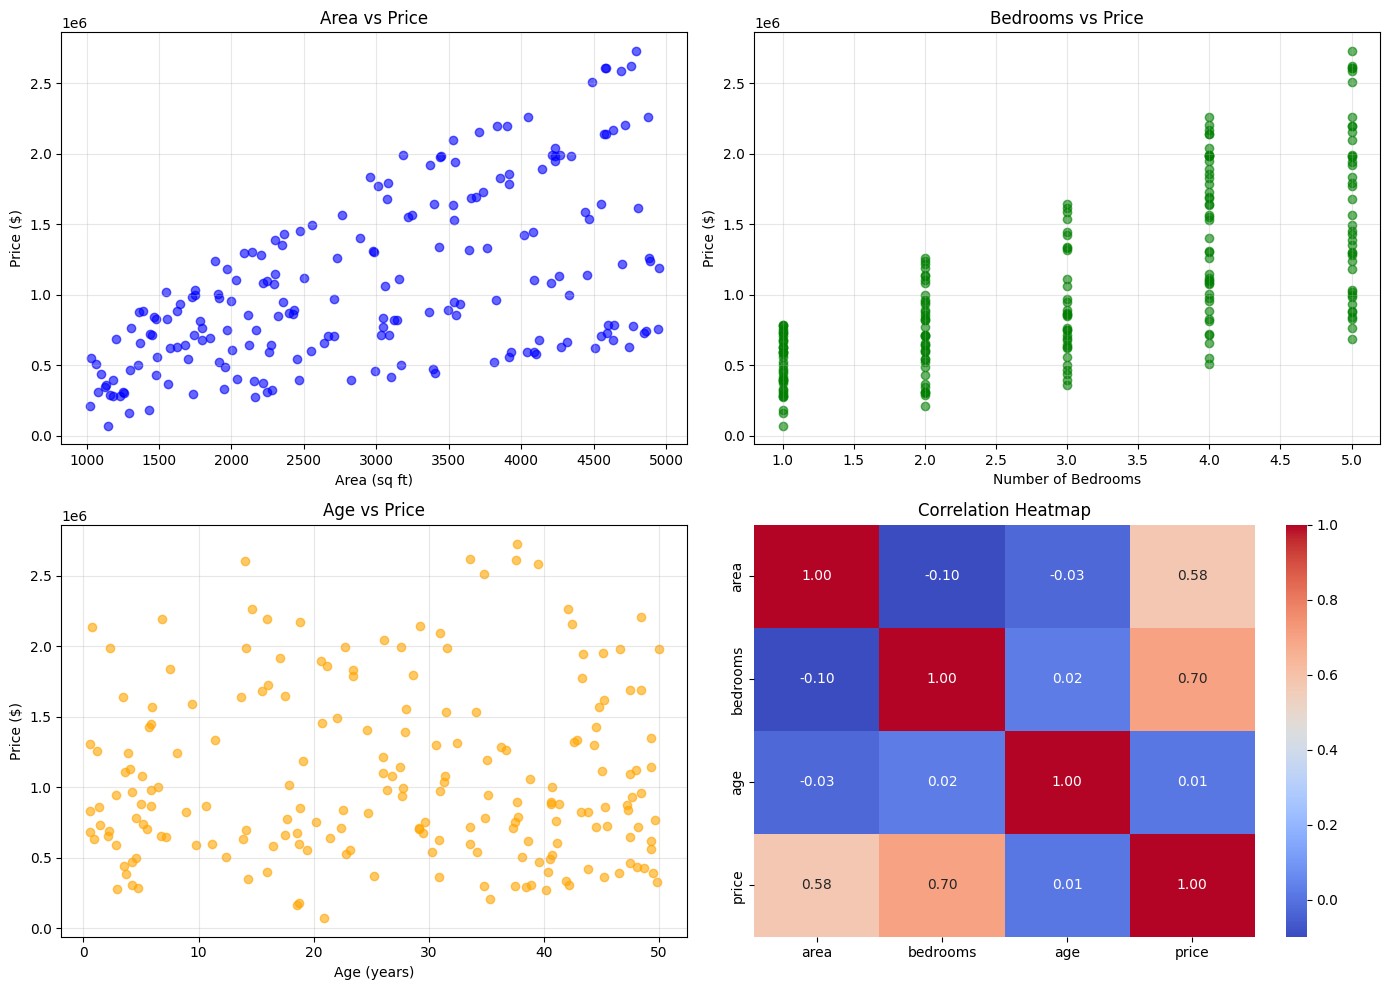

Correlation with price:
price       1.000000
bedrooms    0.703500
area        0.577324
age         0.009274
Name: price, dtype: float64

Price range: $71,119.33 - $2,729,383.61


In [4]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter plot of area vs price
axes[0, 0].scatter(df['area'], df['price'], alpha=0.6, color='blue')
axes[0, 0].set_xlabel('Area (sq ft)')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].set_title('Area vs Price')
axes[0, 0].grid(True, alpha=0.3)

# Scatter plot of bedrooms vs price
axes[0, 1].scatter(df['bedrooms'], df['price'], alpha=0.6, color='green')
axes[0, 1].set_xlabel('Number of Bedrooms')
axes[0, 1].set_ylabel('Price ($)')
axes[0, 1].set_title('Bedrooms vs Price')
axes[0, 1].grid(True, alpha=0.3)

# Scatter plot of age vs price
axes[1, 0].scatter(df['age'], df['price'], alpha=0.6, color='orange')
axes[1, 0].set_xlabel('Age (years)')
axes[1, 0].set_ylabel('Price ($)')
axes[1, 0].set_title('Age vs Price')
axes[1, 0].grid(True, alpha=0.3)

# Correlation heatmap
correlation = df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1], cbar=True)
axes[1, 1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

print(f"Correlation with price:")
print(df.corr()['price'].sort_values(ascending=False))
print(f"\nPrice range: ${df['price'].min():,.2f} - ${df['price'].max():,.2f}")

## Feature Scaling

Normalize all features using StandardScaler for optimal SVR performance.

In [5]:
# Separate features and target
X = df[['area', 'bedrooms', 'age']].values
y = df['price'].values

# Scale the features
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Scale the target for better SVR performance
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

print("Feature scaling completed")
print(f"X shape: {X_scaled.shape}")
print(f"y shape: {y_scaled.shape}")
print(f"\nScaled feature statistics:")
print(f"X mean: {X_scaled.mean():.4f}, std: {X_scaled.std():.4f}")
print(f"y mean: {y_scaled.mean():.4f}, std: {y_scaled.std():.4f}")

Feature scaling completed
X shape: (200, 3)
y shape: (200,)

Scaled feature statistics:
X mean: 0.0000, std: 1.0000
y mean: 0.0000, std: 1.0000


## Theory: Support Vector Regression (SVR)

**Support Vector Regression** extends Support Vector Machines to regression problems.

### Key Concepts:
- **Epsilon-tube (ε)**: SVR tries to fit data within a margin of tolerance
- **Support Vectors**: Data points that lie on or outside the epsilon-tube
- **Kernel Trick**: Allows SVR to model non-linear relationships
- **C Parameter**: Trade-off between model complexity and training error

### Kernel Types:
1. **Linear**: $K(x_i, x_j) = x_i^T x_j$ - Best for linear relationships
2. **RBF (Radial Basis Function)**: $K(x_i, x_j) = \exp(-\gamma ||x_i - x_j||^2)$ - Best for non-linear relationships
3. **Polynomial**: $K(x_i, x_j) = (\gamma x_i^T x_j + r)^d$ - For polynomial relationships

### Evaluation Metrics:
- **MSE (Mean Squared Error)**: $MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$ - Penalizes large errors heavily
- **R² Score**: $R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$ - Proportion of variance explained (0-1 scale)

## Mathematical Representation

SVR optimization problem:

$$\min_{w,b,\xi} \frac{1}{2}||w||^2 + C \sum_{i=1}^{n} (\xi_i + \xi_i^*)$$

Subject to:
- $|y_i - (w^T \phi(x_i) + b)| \leq \epsilon + \xi_i$
- $\xi_i, \xi_i^* \geq 0$

**Prediction function**:
$$f(x) = \sum_{i=1}^{n} (\alpha_i - \alpha_i^*) K(x_i, x) + b$$

where $K(x_i, x)$ is the kernel function.

## Workflow Diagram

Visualize the complete SVR pipeline with kernel comparison.

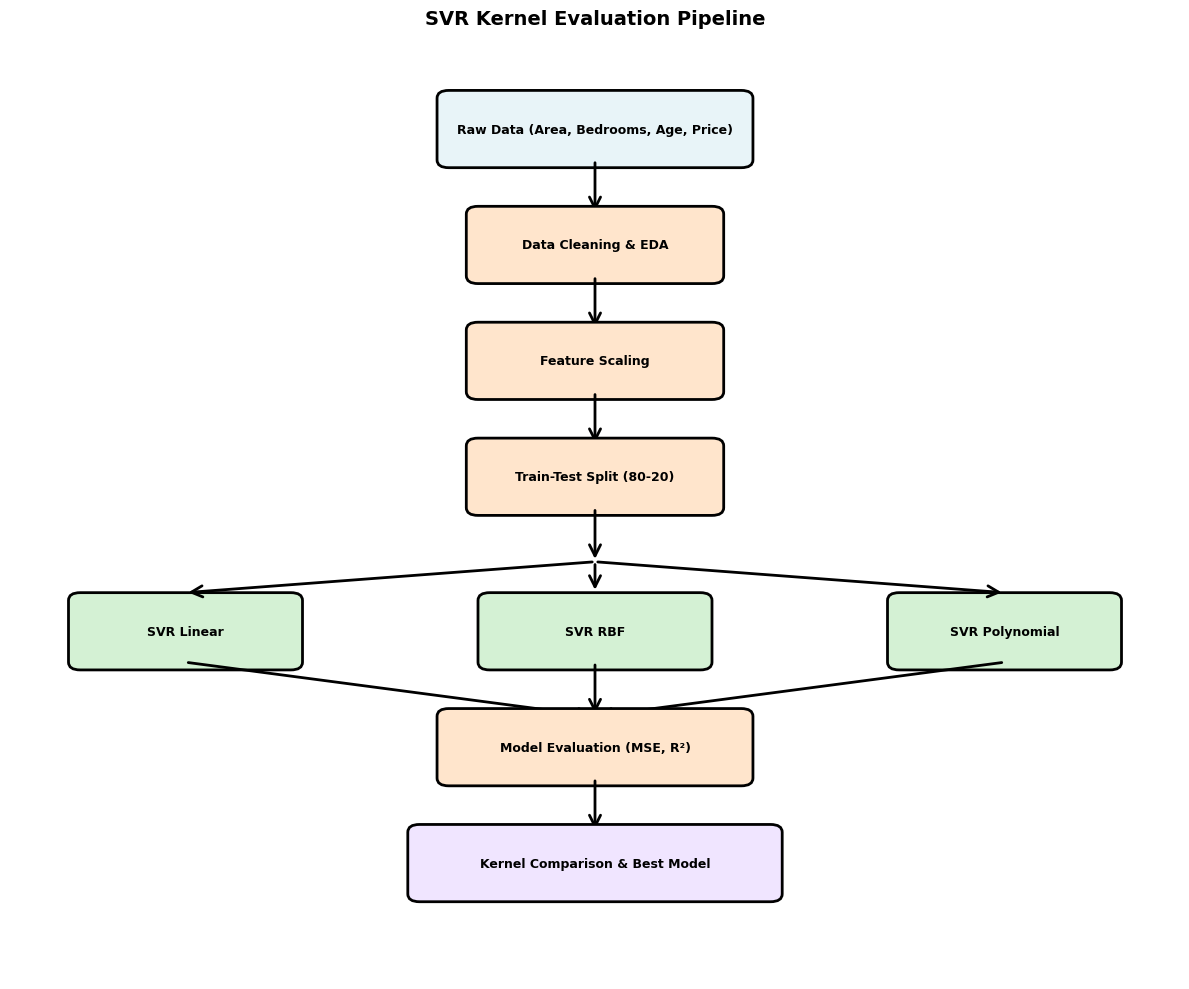

In [6]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

# Define colors
color_input = '#E8F4F8'
color_process = '#FFE5CC'
color_model = '#D4F1D4'
color_output = '#F0E5FF'

# Helper function to create boxes
def add_box(ax, x, y, width, height, text, color):
    box = FancyBboxPatch((x - width/2, y - height/2), width, height,
                         boxstyle="round,pad=0.1", 
                         edgecolor='black', facecolor=color, linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=9, weight='bold', wrap=True)

# Helper function to create arrows
def add_arrow(ax, x1, y1, x2, y2, label=''):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                           arrowstyle='->', mutation_scale=20, 
                           linewidth=2, color='black')
    ax.add_patch(arrow)
    if label:
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mid_x + 0.3, mid_y, label, fontsize=8, style='italic')

# Create workflow
add_box(ax, 5, 11, 2.5, 0.8, 'Raw Data (Area, Bedrooms, Age, Price)', color_input)
add_arrow(ax, 5, 10.6, 5, 9.9)

add_box(ax, 5, 9.5, 2, 0.8, 'Data Cleaning & EDA', color_process)
add_arrow(ax, 5, 9.1, 5, 8.4)

add_box(ax, 5, 8, 2, 0.8, 'Feature Scaling', color_process)
add_arrow(ax, 5, 7.6, 5, 6.9)

add_box(ax, 5, 6.5, 2, 0.8, 'Train-Test Split (80-20)', color_process)
add_arrow(ax, 5, 6.1, 5, 5.4)

# Three SVR models with different kernels
add_box(ax, 1.5, 4.5, 1.8, 0.8, 'SVR Linear', color_model)
add_box(ax, 5, 4.5, 1.8, 0.8, 'SVR RBF', color_model)
add_box(ax, 8.5, 4.5, 1.8, 0.8, 'SVR Polynomial', color_model)

add_arrow(ax, 5, 5.4, 1.5, 5.0)
add_arrow(ax, 5, 5.4, 5, 5.0)
add_arrow(ax, 5, 5.4, 8.5, 5.0)

# Convergence
add_arrow(ax, 1.5, 4.1, 5, 3.4)
add_arrow(ax, 5, 4.1, 5, 3.4)
add_arrow(ax, 8.5, 4.1, 5, 3.4)

add_box(ax, 5, 3, 2.5, 0.8, 'Model Evaluation (MSE, R²)', color_process)
add_arrow(ax, 5, 2.6, 5, 1.9)

add_box(ax, 5, 1.5, 3, 0.8, 'Kernel Comparison & Best Model', color_output)

plt.title('SVR Kernel Evaluation Pipeline', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()

## Pseudocode

```
ALGORITHM: SVR Kernel Evaluation
INPUT: Area, Bedrooms, Age (X), Price (y)

1. DATA PREPARATION
   - Load dataset (area, bedrooms, age, price)
   - Clean data: remove missing values and duplicates
   - Perform EDA: visualize relationships

2. FEATURE SCALING
   - Apply StandardScaler to X and y

3. TRAIN-TEST SPLIT
   - Split data: 80% training, 20% testing

4. SVR MODEL TRAINING (FOR EACH KERNEL)
   - Initialize SVR with kernel='linear' (or 'rbf', 'poly')
   - Train on training data
   - Make predictions on test set

5. EVALUATION FOR EACH KERNEL
   - Calculate MSE = mean((y_true - y_pred)²)
   - Calculate RMSE = sqrt(MSE)
   - Calculate R² = 1 - (SS_res / SS_tot)
   - Store metrics for comparison

6. KERNEL COMPARISON
   - Compare MSE, RMSE, R² across all kernels
   - Identify best performing kernel
   - Visualize metrics comparison

7. MODEL PERSISTENCE
   - Save best model and scalers
```

## Train-Test Split

Split the data into training and testing sets (80-20 split).

In [7]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining set shape: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Testing set shape: X_test {X_test.shape}, y_test {y_test.shape}")

Training set size: 160
Testing set size: 40

Training set shape: X_train (160, 3), y_train (160,)
Testing set shape: X_test (40, 3), y_test (40,)


## SVR Model Training with Different Kernels

Train SVR models using linear, RBF, and polynomial kernels.

In [8]:
# Define kernels to test
kernels = ['linear', 'rbf', 'poly']

# Dictionary to store models and metrics
models = {}
metrics = {}

# Train SVR models with different kernels
for kernel in kernels:
    print(f"\nTraining SVR with {kernel} kernel...")
    
    if kernel == 'poly':
        svr = SVR(kernel=kernel, C=100, degree=3, epsilon=0.1)
    else:
        svr = SVR(kernel=kernel, C=100, epsilon=0.1)
    
    svr.fit(X_train, y_train)
    models[kernel] = svr
    print(f"✓ SVR {kernel} model trained successfully!")
    print(f"  Support vectors: {len(svr.support_vectors_)}")


Training SVR with linear kernel...
✓ SVR linear model trained successfully!
  Support vectors: 117

Training SVR with rbf kernel...
✓ SVR rbf model trained successfully!
  Support vectors: 70

Training SVR with poly kernel...
✓ SVR poly model trained successfully!
  Support vectors: 130


## Making Predictions

Generate predictions for all kernel models.

In [9]:
# Make predictions for all kernels
predictions = {}

for kernel in kernels:
    # Predictions on scaled data
    y_pred_scaled = models[kernel].predict(X_test)
    
    # Inverse scale to original price values
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    predictions[kernel] = y_pred

# Inverse scale actual test values
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

print("Predictions made successfully for all kernels!")
print(f"\nTest set size: {len(y_test_original)}")
print(f"\nFirst 5 predictions (Original Price Scale):")
print(f"{'Actual':>15} | {'Linear':>15} | {'RBF':>15} | {'Polynomial':>15}")
print("-" * 65)
for i in range(5):
    print(f"${y_test_original[i]:>13,.2f} | ${predictions['linear'][i]:>13,.2f} | ${predictions['rbf'][i]:>13,.2f} | ${predictions['poly'][i]:>13,.2f}")

Predictions made successfully for all kernels!

Test set size: 40

First 5 predictions (Original Price Scale):
         Actual |          Linear |             RBF |      Polynomial
-----------------------------------------------------------------
$ 1,312,357.71 | $ 1,384,693.75 | $ 1,396,312.42 | $ 1,081,359.31
$   296,107.90 | $    18,880.17 | $   273,887.21 | $  -120,184.89
$ 1,337,338.73 | $ 1,210,904.59 | $ 1,185,623.85 | $ 1,079,746.30
$   333,141.10 | $    87,669.14 | $   322,975.05 | $  -137,612.96
$   550,643.98 | $   749,843.39 | $   440,240.54 | $   836,608.07


## Evaluation Metrics: MSE and R² Score

Calculate and compare Mean Squared Error and R² score for all kernels.

In [10]:
# Calculate metrics for all kernels
print("\n" + "="*80)
print("SVR KERNEL COMPARISON - EVALUATION METRICS")
print("="*80)

for kernel in kernels:
    # Calculate metrics on original scale
    mse = mean_squared_error(y_test_original, predictions[kernel])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_original, predictions[kernel])
    r2 = r2_score(y_test_original, predictions[kernel])
    
    # Store metrics
    metrics[kernel] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }
    
    print(f"\n{kernel.upper()} Kernel:")
    print(f"  Mean Squared Error (MSE):      ${mse:>15,.2f}")
    print(f"  Root Mean Squared Error (RMSE): ${rmse:>14,.2f}")
    print(f"  Mean Absolute Error (MAE):     ${mae:>15,.2f}")
    print(f"  R² Score:                       {r2:>16.6f}")
    print(f"  Variance Explained:             {r2*100:>15.2f}%")

print("\n" + "="*80)


SVR KERNEL COMPARISON - EVALUATION METRICS

LINEAR Kernel:
  Mean Squared Error (MSE):      $31,027,732,209.64
  Root Mean Squared Error (RMSE): $    176,146.91
  Mean Absolute Error (MAE):     $     140,382.76
  R² Score:                               0.925236
  Variance Explained:                       92.52%

RBF Kernel:
  Mean Squared Error (MSE):      $3,859,779,815.05
  Root Mean Squared Error (RMSE): $     62,127.13
  Mean Absolute Error (MAE):     $      49,539.44
  R² Score:                               0.990700
  Variance Explained:                       99.07%

POLY Kernel:
  Mean Squared Error (MSE):      $62,275,804,352.10
  Root Mean Squared Error (RMSE): $    249,551.21
  Mean Absolute Error (MAE):     $     197,705.16
  R² Score:                               0.849942
  Variance Explained:                       84.99%



## Kernel Comparison Visualization

Compare the performance of different kernels using MSE and R² metrics.

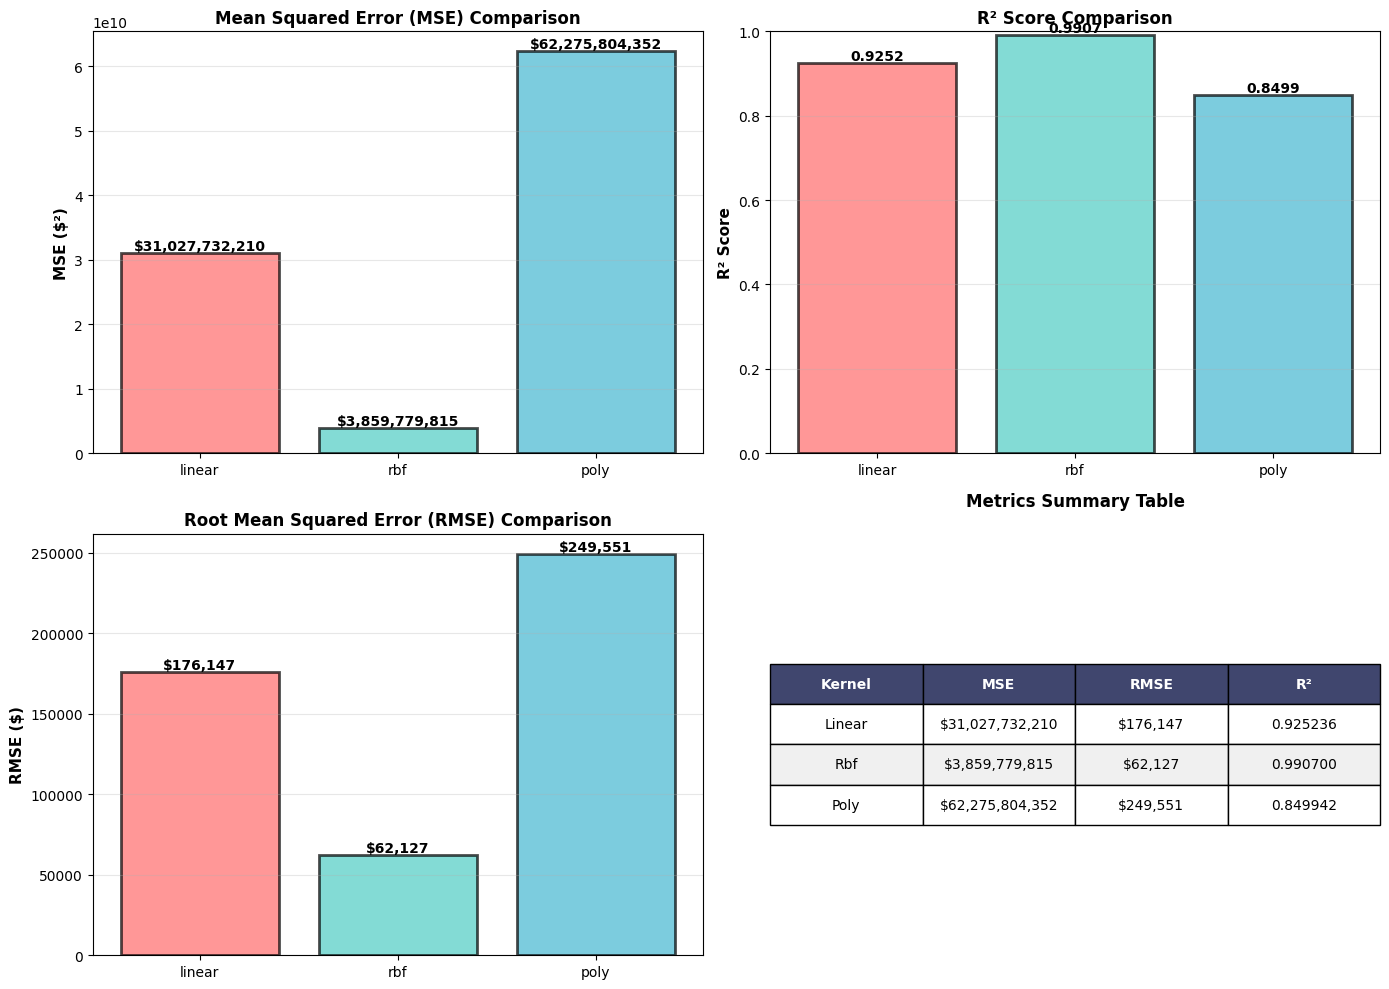


✓ Best performing kernel (lowest MSE): RBF
  MSE: $3,859,779,815.05
  R²: 0.990700


In [11]:
# Prepare comparison data
kernel_names = list(kernels)
mse_values = [metrics[k]['MSE'] for k in kernels]
r2_values = [metrics[k]['R2'] for k in kernels]
rmse_values = [metrics[k]['RMSE'] for k in kernels]

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: MSE Comparison
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars1 = axes[0, 0].bar(kernel_names, mse_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0, 0].set_ylabel('MSE ($²)', fontsize=11, weight='bold')
axes[0, 0].set_title('Mean Squared Error (MSE) Comparison', fontsize=12, weight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')
for i, (bar, val) in enumerate(zip(bars1, mse_values)):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, val, f'${val:,.0f}', 
                    ha='center', va='bottom', fontsize=10, weight='bold')

# Plot 2: R² Score Comparison
bars2 = axes[0, 1].bar(kernel_names, r2_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0, 1].set_ylabel('R² Score', fontsize=11, weight='bold')
axes[0, 1].set_title('R² Score Comparison', fontsize=12, weight='bold')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, (bar, val) in enumerate(zip(bars2, r2_values)):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, val, f'{val:.4f}', 
                    ha='center', va='bottom', fontsize=10, weight='bold')

# Plot 3: RMSE Comparison
bars3 = axes[1, 0].bar(kernel_names, rmse_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('RMSE ($)', fontsize=11, weight='bold')
axes[1, 0].set_title('Root Mean Squared Error (RMSE) Comparison', fontsize=12, weight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for i, (bar, val) in enumerate(zip(bars3, rmse_values)):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, val, f'${val:,.0f}', 
                    ha='center', va='bottom', fontsize=10, weight='bold')

# Plot 4: Combined Metrics Table
axes[1, 1].axis('off')
table_data = []
table_data.append(['Kernel', 'MSE', 'RMSE', 'R²'])
for kernel in kernels:
    table_data.append([
        kernel.capitalize(),
        f"${metrics[kernel]['MSE']:,.0f}",
        f"${metrics[kernel]['RMSE']:,.0f}",
        f"{metrics[kernel]['R2']:.6f}"
    ])

table = axes[1, 1].table(cellText=table_data, cellLoc='center', loc='center',
                         colWidths=[0.25, 0.25, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header row
for i in range(4):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(table_data)):
    for j in range(4):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')
        else:
            table[(i, j)].set_facecolor('#ffffff')

axes[1, 1].set_title('Metrics Summary Table', fontsize=12, weight='bold', pad=20)

plt.tight_layout()
plt.show()

# Find best kernel
best_kernel = min(metrics.keys(), key=lambda k: metrics[k]['MSE'])
print(f"\n✓ Best performing kernel (lowest MSE): {best_kernel.upper()}")
print(f"  MSE: ${metrics[best_kernel]['MSE']:,.2f}")
print(f"  R²: {metrics[best_kernel]['R2']:.6f}")

## Actual vs Predicted Values (Best Kernel)

Visualize the actual vs predicted values for the best performing kernel.

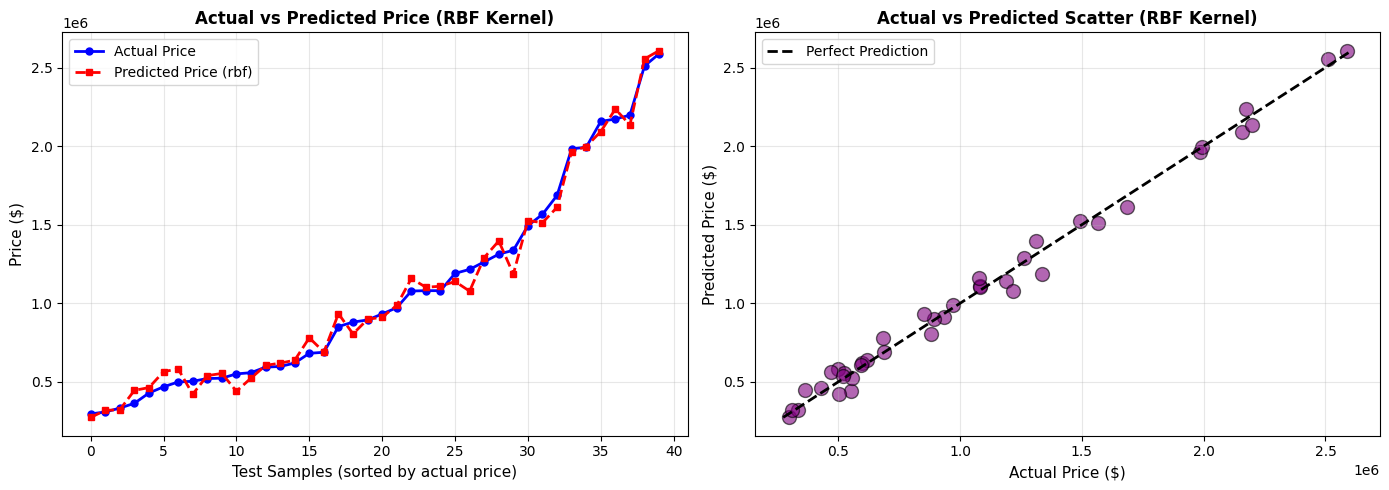


Actual Price Range: $296,107.90 - $2,587,270.18
Predicted Price Range: $273,887.21 - $2,607,302.75


In [12]:
# Get predictions from best kernel
best_predictions = predictions[best_kernel]

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sort by actual values
sorted_indices = np.argsort(y_test_original)
sorted_actual = y_test_original[sorted_indices]
sorted_pred = best_predictions[sorted_indices]

# Plot 1: Actual vs Predicted Line Plot
x_axis = np.arange(len(sorted_actual))
axes[0].plot(x_axis, sorted_actual, 'o-', label='Actual Price', color='blue', linewidth=2, markersize=5)
axes[0].plot(x_axis, sorted_pred, 's--', label=f'Predicted Price ({best_kernel})', color='red', linewidth=2, markersize=5)
axes[0].set_xlabel('Test Samples (sorted by actual price)', fontsize=11)
axes[0].set_ylabel('Price ($)', fontsize=11)
axes[0].set_title(f'Actual vs Predicted Price ({best_kernel.upper()} Kernel)', fontsize=12, weight='bold')
axes[0].legend(loc='best', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Scatter Plot - Actual vs Predicted
axes[1].scatter(y_test_original, best_predictions, alpha=0.6, color='purple', s=100, edgecolors='black', linewidth=1)
# Add perfect prediction line
min_val = min(y_test_original.min(), best_predictions.min())
max_val = max(y_test_original.max(), best_predictions.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price ($)', fontsize=11)
axes[1].set_ylabel('Predicted Price ($)', fontsize=11)
axes[1].set_title(f'Actual vs Predicted Scatter ({best_kernel.upper()} Kernel)', fontsize=12, weight='bold')
axes[1].legend(loc='best', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nActual Price Range: ${y_test_original.min():,.2f} - ${y_test_original.max():,.2f}")
print(f"Predicted Price Range: ${best_predictions.min():,.2f} - ${best_predictions.max():,.2f}")

## Residuals Analysis (Best Kernel)

Analyze the prediction errors for the best kernel.

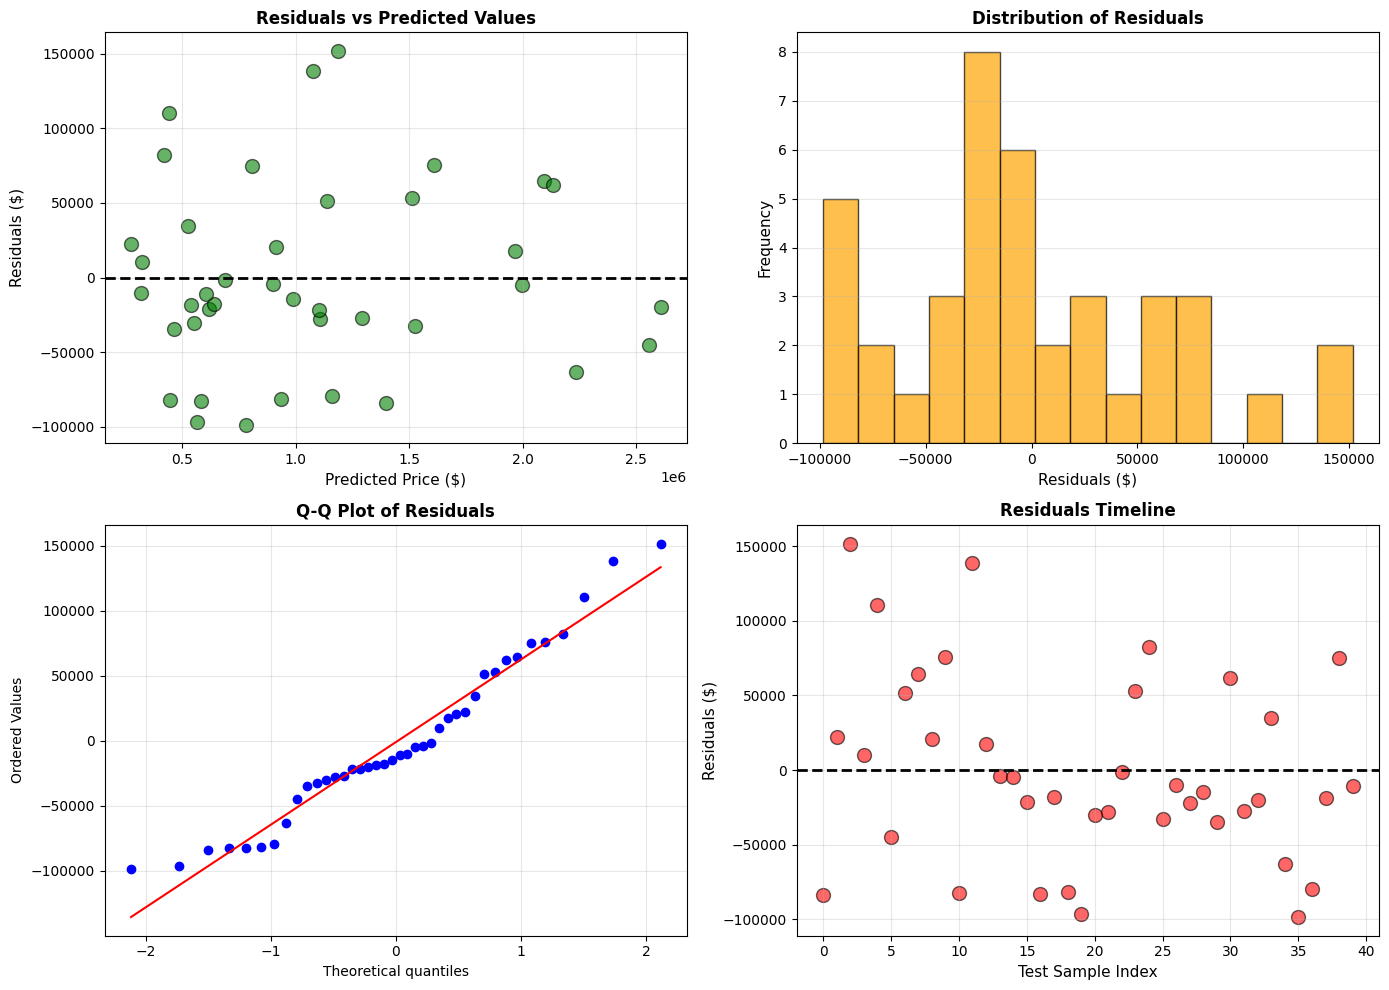


Residuals Statistics:
  Mean: $-1,054.52
  Std Dev: $62,118.18
  Min: $-98,470.90
  Max: $151,714.88


In [13]:
# Calculate residuals
residuals = y_test_original - best_predictions

# Create residuals visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Residuals vs Predicted Values
axes[0, 0].scatter(best_predictions, residuals, alpha=0.6, color='green', s=100, edgecolors='black', linewidth=1)
axes[0, 0].axhline(y=0, color='k', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Price ($)', fontsize=11)
axes[0, 0].set_ylabel('Residuals ($)', fontsize=11)
axes[0, 0].set_title('Residuals vs Predicted Values', fontsize=12, weight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals Distribution
axes[0, 1].hist(residuals, bins=15, color='orange', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Residuals ($)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Distribution of Residuals', fontsize=12, weight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Q-Q Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot of Residuals', fontsize=12, weight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Residuals Timeline
axes[1, 1].scatter(np.arange(len(residuals)), residuals, alpha=0.6, color='red', s=100, edgecolors='black', linewidth=1)
axes[1, 1].axhline(y=0, color='k', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Test Sample Index', fontsize=11)
axes[1, 1].set_ylabel('Residuals ($)', fontsize=11)
axes[1, 1].set_title('Residuals Timeline', fontsize=12, weight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResiduals Statistics:")
print(f"  Mean: ${residuals.mean():,.2f}")
print(f"  Std Dev: ${residuals.std():,.2f}")
print(f"  Min: ${residuals.min():,.2f}")
print(f"  Max: ${residuals.max():,.2f}")

## Model Persistence

Save the best model and scalers for future use.

In [14]:
# Save the best model and scalers
model_path = f'svr_{best_kernel}_model.joblib'
scaler_x_path = 'scaler_X_house.joblib'
scaler_y_path = 'scaler_y_house.joblib'

joblib.dump(models[best_kernel], model_path)
joblib.dump(scaler_X, scaler_x_path)
joblib.dump(scaler_y, scaler_y_path)

print(f"✓ Best model ({best_kernel} kernel) saved to: {model_path}")
print(f"✓ X Scaler saved to: {scaler_x_path}")
print(f"✓ y Scaler saved to: {scaler_y_path}")

# Example: Predict price for new data
new_data = np.array([
    [3000, 4, 10],  # 3000 sq ft, 4 bedrooms, 10 years old
    [2000, 3, 5],   # 2000 sq ft, 3 bedrooms, 5 years old
    [4000, 5, 20]   # 4000 sq ft, 5 bedrooms, 20 years old
])

new_data_scaled = scaler_X.transform(new_data)
new_predictions_scaled = models[best_kernel].predict(new_data_scaled)
new_predictions = scaler_y.inverse_transform(new_predictions_scaled.reshape(-1, 1)).ravel()

print(f"\n{'='*60}")
print("PREDICTIONS FOR NEW DATA")
print(f"{'='*60}")
print(f"{'Area (sq ft)':>15} | {'Bedrooms':>10} | {'Age (years)':>12} | {'Predicted Price':>18}")
print("-" * 60)
for i, (area, beds, age) in enumerate(new_data):
    print(f"{area:>15,.0f} | {beds:>10.0f} | {age:>12.0f} | ${new_predictions[i]:>16,.2f}")
print(f"{'='*60}")

print("\n✓ SVR Kernel Evaluation Model completed successfully!")

✓ Best model (rbf kernel) saved to: svr_rbf_model.joblib
✓ X Scaler saved to: scaler_X_house.joblib
✓ y Scaler saved to: scaler_y_house.joblib

PREDICTIONS FOR NEW DATA
   Area (sq ft) |   Bedrooms |  Age (years) |    Predicted Price
------------------------------------------------------------
          3,000 |          4 |           10 | $    1,404,797.69
          2,000 |          3 |            5 | $      788,854.18
          4,000 |          5 |           20 | $    2,244,643.92

✓ SVR Kernel Evaluation Model completed successfully!
